<a href="https://colab.research.google.com/github/Keshh2601/Election-Prediction/blob/main/Copy_of_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('indian-national-level-election.csv')

In [ ]:
print(df.head())

                     st_name  year  pc_no                    pc_name pc_type  \
0  Andaman & Nicobar Islands  1977      1  Andaman & Nicobar Islands     GEN   
1  Andaman & Nicobar Islands  1977      1  Andaman & Nicobar Islands     GEN   
2  Andaman & Nicobar Islands  1980      1  Andaman & Nicobar Islands     GEN   
3  Andaman & Nicobar Islands  1980      1  Andaman & Nicobar Islands     GEN   
4  Andaman & Nicobar Islands  1980      1  Andaman & Nicobar Islands     GEN   

           cand_name cand_sex                 partyname partyabbre  \
0        K.R. Ganesh        M              Independents        IND   
1  Manoranjan Bhakta        M  Indian National Congress        INC   
2    Ramesh Mazumdar        M              Independents        IND   
3      Alagiri Swamy        M              Independents        IND   
4        Kannu Chemy        M              Independents        IND   

   totvotpoll  electors  
0       25168     85308  
1       35400     85308  
2         109     96

In [ ]:
print(df.shape)

(73081, 11)


In [ ]:
print(df.columns)

Index(['st_name', 'year', 'pc_no', 'pc_name', 'pc_type', 'cand_name',
       'cand_sex', 'partyname', 'partyabbre', 'totvotpoll', 'electors'],
      dtype='object')


In [ ]:
#Create Winner Column
# Find maximum votes in each constituency
max_votes = df.groupby(['year', 'pc_name'])['totvotpoll'].transform('max')

# Create winner column
df['winner'] = np.where(df['totvotpoll'] == max_votes, 1, 0)

print(df[['cand_name', 'totvotpoll', 'winner']].head())

           cand_name  totvotpoll  winner
0        K.R. Ganesh       25168       0
1  Manoranjan Bhakta       35400       1
2    Ramesh Mazumdar         109       0
3      Alagiri Swamy         125       0
4        Kannu Chemy         405       0


In [ ]:
#Handle Missing Values
print(df.isnull().sum())

# Remove missing values if any
df.dropna(inplace=True)

st_name          0
year             0
pc_no            0
pc_name          0
pc_type       8070
cand_name        0
cand_sex       542
partyname        0
partyabbre       0
totvotpoll       0
electors         0
winner           0
dtype: int64


In [ ]:
#Encode Categorical Data
label_encoder = LabelEncoder()

categorical_columns = ['st_name', 'pc_name', 'pc_type',
                       'cand_name', 'cand_sex',
                       'partyname', 'partyabbre']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
#Feature Selection
X = df[['st_name', 'year', 'pc_no', 'pc_name',
        'pc_type', 'cand_sex', 'partyname',
        'partyabbre', 'totvotpoll', 'electors']]

y = df['winner']

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Logistic Regression Model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=5000,
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy: 0.9548627268496975


In [ ]:
#Decision Tree Model
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print('Decision Tree Accuracy:',
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9540871723282147


In [ ]:
#Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print('Random Forest Accuracy:',
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9692880409492788


In [ ]:
#Model Comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.954863
1        Decision Tree  0.954087
2        Random Forest  0.969288


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train Model
xgb_model.fit(X_train, y_train)

# Prediction
xgb_pred = xgb_model.predict(X_test)

# Accuracy
print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9691329300449821


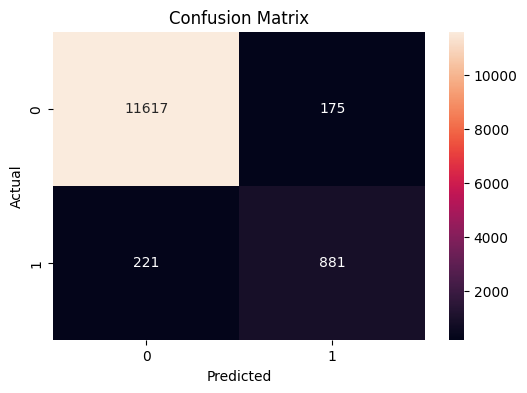

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#Classification Report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11792
           1       0.83      0.80      0.82      1102

    accuracy                           0.97     12894
   macro avg       0.91      0.89      0.90     12894
weighted avg       0.97      0.97      0.97     12894



In [ ]:
#Feature Importance
importance = rf_model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

print(feature_df)

      Feature  Importance
8  totvotpoll    0.487673
9    electors    0.104640
7  partyabbre    0.099355
6   partyname    0.078449
2       pc_no    0.054329
0     st_name    0.053834
1        year    0.053612
3     pc_name    0.053599
4     pc_type    0.010164
5    cand_sex    0.004347


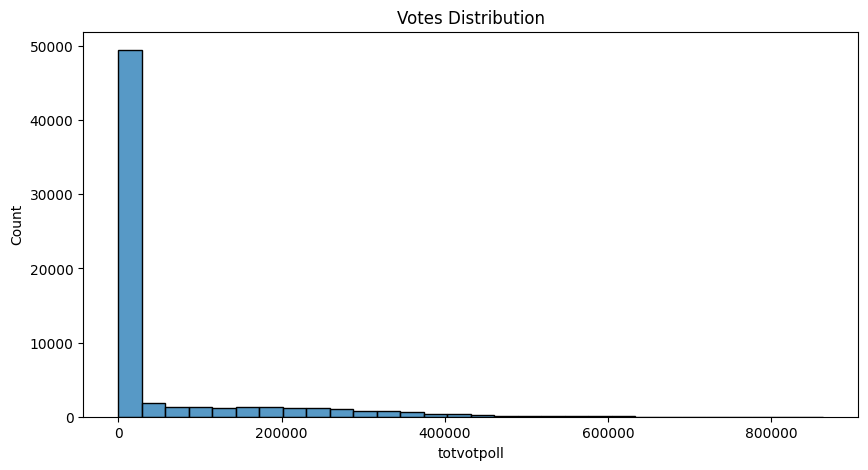

In [ ]:
#Votes Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['totvotpoll'], bins=30)
plt.title('Votes Distribution')
plt.show()

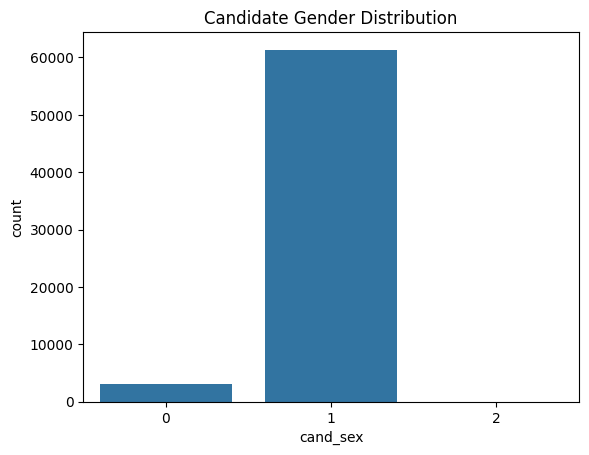

In [ ]:
#Gender Distribution
sns.countplot(x='cand_sex', data=df)
plt.title('Candidate Gender Distribution')
plt.show()

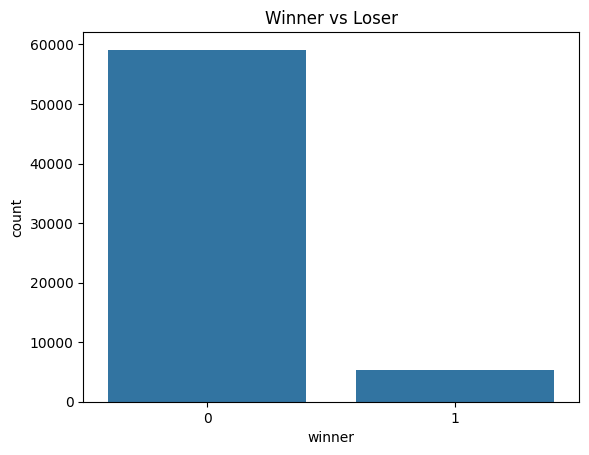

In [ ]:
#Winners vs Losers
sns.countplot(x='winner', data=df)
plt.title('Winner vs Loser')
plt.show()

In [ ]:
sample_input = pd.DataFrame([[
    1,      # st_name
    2014,   # year
    10,     # pc_no
    50,     # pc_name
    1,      # pc_type
    1,      # cand_sex
    20,     # partyname
    20,     # partyabbre
    500000, # totvotpoll
    1000000 # electors
]], columns=[
    'st_name',
    'year',
    'pc_no',
    'pc_name',
    'pc_type',
    'cand_sex',
    'partyname',
    'partyabbre',
    'totvotpoll',
    'electors'
])

prediction = rf_model.predict(sample_input)

if prediction[0] == 1:
    print("Predicted Result: Winner")
else:
    print("Predicted Result: Loser")

Predicted Result: Winner
